In [1]:
import pandas as pd
import numpy as np
import transformers
from transformers import RobertaTokenizer, RobertaForSequenceClassification

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader

import copy


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm.auto import tqdm

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

cpu


In [3]:
model_name = "roberta-base"
num_labels = 4

In [4]:
tokenizer = RobertaTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [5]:
train = pd.read_csv("work/data/train.csv")
test = pd.read_csv("work/data/test.csv")

## EDA

In [6]:
train.shape, test.shape

((120000, 3), (7600, 3))

In [7]:
train.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [8]:
test.head()

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [9]:
train.rename(columns={
    "Class Index": "label",
    "Title": "title",
    "Description": "description"
}, inplace=True)

test.rename(columns={
    "Class Index": "label",
    "Title": "title",
    "Description": "description"
}, inplace=True)

In [10]:
train.label.value_counts()

label
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64

In [11]:
test.label.value_counts()

label
3    1900
4    1900
2    1900
1    1900
Name: count, dtype: int64

In [12]:
def text_len(tokenizer, texts):
    token_counts = []
    for text in texts:
        token_counts.append(len(tokenizer.encode(text, add_special_tokens=False)))

    token_counts = np.array(token_counts)

    return {
        "Медиана": np.median(token_counts),
        "Среднее": np.mean(token_counts),
        "Максимум": np.max(token_counts), 
        "Минимум": np.min(token_counts)
    }

In [13]:
res = {
    "train": {"descriptions": {}, "title": {}},
    "test":  {"descriptions": {}, "title": {}},
}

In [14]:
for label in range(1, 5):
    res["train"]["descriptions"][f"label {label}"] = text_len(
        tokenizer, train.loc[train.label == label, "description"].tolist()
    )
    res["train"]["title"][f"label {label}"] = text_len(
        tokenizer, train.loc[train.label == label, "title"].tolist()
    )
    res["test"]["descriptions"][f"label {label}"] = text_len(
        tokenizer, test.loc[test.label == label, "description"].tolist()
    )
    res["test"]["title"][f"label {label}"] = text_len(
        tokenizer, test.loc[test.label == label, "title"].tolist()
    )

In [15]:
records = []
for split, fields in res.items():
    for field, labels in fields.items():
        for label, stats in labels.items():
            records.append({
                "split": split,
                "field": field,
                "label": label,
                "Медиана": stats["Медиана"],
                "Среднее": stats["Среднее"],
                "Максимум": stats["Максимум"],
                "Минимум": stats["Минимум"],
            })

df_stats = pd.DataFrame(records)
df_stats["label"] = pd.Categorical(
    df_stats["label"], categories=[f"label {i}" for i in range(1, 5)], ordered=True
)


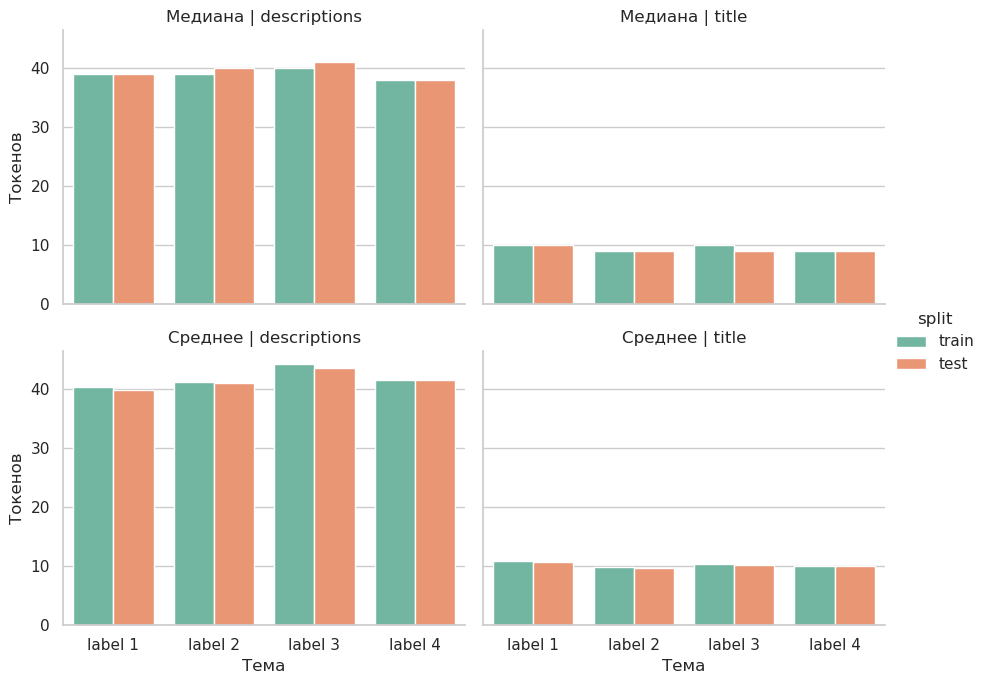

In [16]:
sns.set_theme(style="whitegrid")

long_df = df_stats.melt(
    id_vars=["split", "field", "label"],
    value_vars=["Медиана", "Среднее"],
    var_name="metric", value_name="tokens"
)

g = sns.catplot(
    data=long_df,
    x="label", y="tokens",
    hue="split", col="field", row="metric",
    kind="bar", height=3.5, aspect=1.3,
    palette="Set2",
)
g.set_axis_labels("Тема", "Токенов")
g.set_titles("{row_name} | {col_name}")
plt.show()

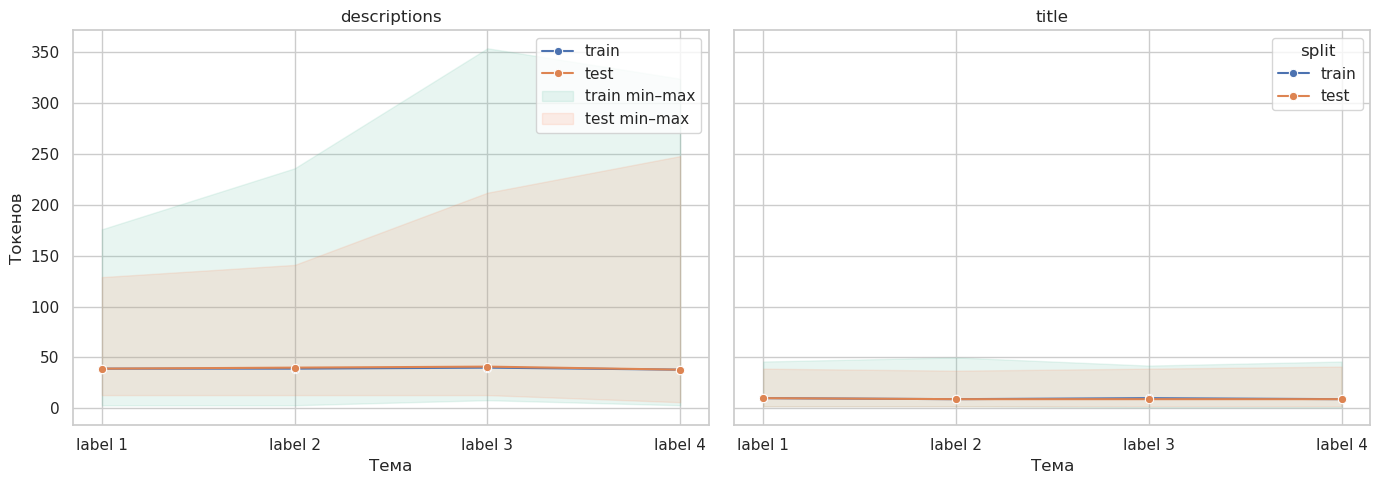

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, field in zip(axes, ["descriptions", "title"]):
    sub = df_stats[df_stats["field"] == field]
    sns.lineplot(
        data=sub, x="label", y="Медиана",
        hue="split", marker="o", ax=ax,
    )
    # полоса min–max через fill_between
    for split, color in zip(["train", "test"], sns.color_palette("Set2")):
        s = sub[sub["split"] == split].sort_values("label")
        ax.fill_between(
            range(len(s)), s["Минимум"], s["Максимум"],
            alpha=0.15, color=color, label=f"{split} min–max",
        )
    ax.set_title(field)
    ax.set_xlabel("Тема")
    ax.set_ylabel("Токенов")

axes[0].legend()
plt.tight_layout()
plt.show()

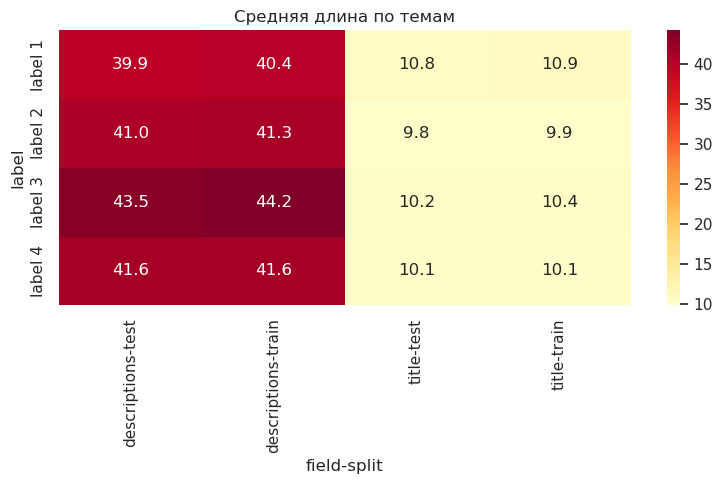

In [18]:
heat = df_stats.pivot_table(
    index="label",
    columns=["field", "split"],
    values="Среднее",
)

plt.figure(figsize=(8, 5))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Средняя длина по темам")
plt.tight_layout()
plt.show()

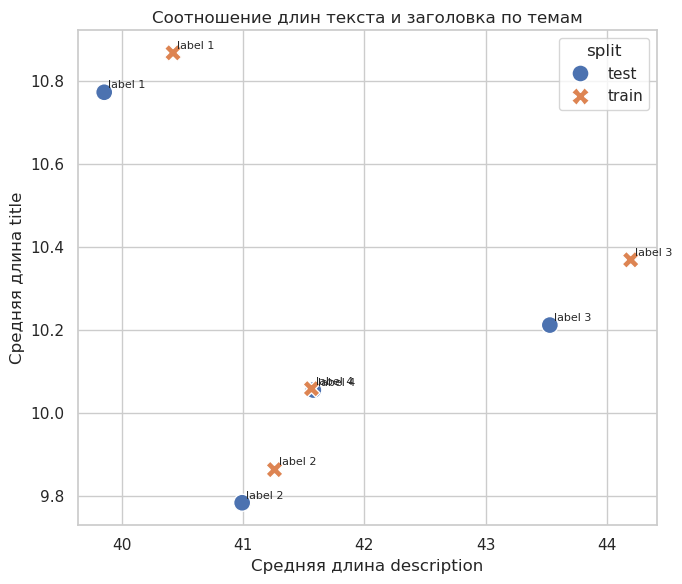

In [19]:
pivot = df_stats.pivot_table(
    index=["split", "label"], columns="field", values="Среднее"
).reset_index()

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=pivot, x="descriptions", y="title",
    hue="split", style="split", s=150,
)
for _, r in pivot.iterrows():
    plt.annotate(r["label"], (r["descriptions"], r["title"]),
                 fontsize=8, xytext=(3, 3), textcoords="offset points")
plt.xlabel("Средняя длина description")
plt.ylabel("Средняя длина title")
plt.title("Соотношение длин текста и заголовка по темам")
plt.tight_layout()
plt.show()

## Pipeline

In [20]:
tokenizer.SPECIAL_TOKENS_ATTRIBUTES

['bos_token',
 'eos_token',
 'unk_token',
 'sep_token',
 'pad_token',
 'cls_token',
 'mask_token']

In [21]:
row = train.loc[0]

In [22]:
desc = row.description
title = row.title

In [23]:
desc, title

("Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
 'Wall St. Bears Claw Back Into the Black (Reuters)')

In [24]:
tokenizer.decode(tokenizer(desc, title)["input_ids"])

"<s>Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.</s></s>Wall St. Bears Claw Back Into the Black (Reuters)</s>"

In [25]:
def token_lengths(tokenizer, titles, texts):
    enc = tokenizer(
        titles, texts,
        add_special_tokens=True,
        truncation=False,
    )
    return np.array([len(ids) for ids in enc["input_ids"]])

lens_train = token_lengths(tokenizer, train["title"].tolist(), train["description"].tolist())

for q in [50, 90, 95, 99, 99.5, 100]:
    print(f"p{q}: {np.percentile(lens_train, q):.0f}")

print("доля > 256:", (lens_train > 256).mean())
print("доля > 384:", (lens_train > 384).mean())

p50: 54
p90: 73
p95: 84
p99: 124
p99.5: 140
p100: 364
доля > 256: 0.0004
доля > 384: 0.0


In [26]:
MAX_LEN = int(min(512, np.percentile(lens_train, 99)))
MAX_LEN

124

In [27]:
def encode_split(df):
    enc = tokenizer(
        df["title"].tolist(),
        df["description"].tolist(),
        add_special_tokens=True,
        truncation=True,
        max_length=MAX_LEN,
        padding=False,
        return_attention_mask=True,
    )
    return enc["input_ids"], enc["attention_mask"], df["label"] - 1


In [28]:
train_ids, train_mask, train_y = encode_split(train)
test_ids,  test_mask,  test_y  = encode_split(test)

In [29]:
vocab = tokenizer.get_vocab()
len(vocab)

50265

In [30]:
class TopicDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.attention_mask[idx], dtype=torch.long),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [31]:
def collate_fn(batch):
    max_len = max(len(b["input_ids"]) for b in batch)
    pad_id = tokenizer.pad_token_id

    input_ids, attn, labels = [], [], []
    for b in batch:
        pad = max_len - len(b["input_ids"])
        input_ids.append(torch.cat([b["input_ids"], torch.full((pad,), pad_id, dtype=torch.long)]))
        attn.append(torch.cat([b["attention_mask"], torch.zeros(pad, dtype=torch.long)]))
        labels.append(b["labels"])

    return {
        "input_ids": torch.stack(input_ids),
        "attention_mask": torch.stack(attn),
        "labels": torch.stack(labels),
    }

In [32]:
BATCH_SIZE = 32

train_ds = TopicDataset(train_ids, train_mask, train_y)
test_ds  = TopicDataset(test_ids,  test_mask,  test_y)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2)

In [33]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, preds_all, y_all = 0, [], []
    for batch in tqdm(loader, leave=False):
        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        y = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, mask)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # важно для RNN
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        preds_all.append(logits.argmax(-1).cpu())
        y_all.append(y.cpu())

    preds_all = torch.cat(preds_all).numpy()
    y_all = torch.cat(y_all).numpy()
    return total_loss / len(y_all), accuracy_score(y_all, preds_all), f1_score(y_all, preds_all, average="macro")


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, preds_all, y_all = 0, [], []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        y = batch["labels"].to(device)

        logits = model(input_ids, mask)
        loss = criterion(logits, y)

        total_loss += loss.item() * y.size(0)
        preds_all.append(logits.argmax(-1).cpu())
        y_all.append(y.cpu())

    preds_all = torch.cat(preds_all).numpy()
    y_all = torch.cat(y_all).numpy()
    return total_loss / len(y_all), accuracy_score(y_all, preds_all), f1_score(y_all, preds_all, average="macro")

In [34]:
import os
import json

def train(
    model,
    train_loader,
    test_loader,
    num_epochs,
    model_name="model",
    save_dir="work/models",
    save_checkpoint=True,
    patience=1,
    min_delta=1e-2,
    lr=1e-3,
    weight_decay=1e-2,
    restore_best=True,
):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    if save_checkpoint:
        model_dir = os.path.join(save_dir, model_name)
        os.makedirs(model_dir, exist_ok=True)
        ckpt_path = os.path.join(model_dir, f"{model_name}_best.pt")
        metrics_path = os.path.join(model_dir, f"{model_name}_metrics.json")

    best_f1 = -float("inf")
    best_state = None
    best_epoch = -1
    epochs_no_improve = 0
    history = []

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc, tr_f1 = train_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc, va_f1 = evaluate(model, test_loader, criterion)

        history.append({
            "epoch": epoch,
            "tr_loss": tr_loss, "tr_acc": tr_acc, "tr_f1": tr_f1,
            "va_loss": va_loss, "va_acc": va_acc, "va_f1": va_f1,
        })

        improved = va_f1 > best_f1 + min_delta
        marker = ""

        if improved:
            best_f1 = va_f1
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            marker = " *"

            if save_checkpoint:
                torch.save({
                    "model_name": model_name,
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_f1": float(va_f1),
                    "va_acc": float(va_acc),
                    "va_loss": float(va_loss),
                }, ckpt_path)
        else:
            epochs_no_improve += 1

        print(
            f"epoch {epoch:2d} | "
            f"train loss {tr_loss:.4f} acc {tr_acc:.4f} f1 {tr_f1:.4f} | "
            f"val loss {va_loss:.4f} acc {va_acc:.4f} f1 {va_f1:.4f} | "
            f"no-improve {epochs_no_improve}/{patience}{marker}"
        )

        if epochs_no_improve >= patience:
            print(f"Ранняя остановка на эпохе {epoch} (лучшая: {best_epoch}, F1={best_f1:.4f})")
            break

    if restore_best and best_state is not None:
        model.load_state_dict(best_state)
    if save_checkpoint:
        serializable_history = []
        for h in history:
            serializable_history.append({
                k: (float(v) if isinstance(v, (float, np.floating, np.integer)) else v)
                for k, v in h.items()
            })

        metrics = {
            "model_name": model_name,
            "best_f1": float(best_f1),
            "best_epoch": int(best_epoch),
            "num_params": sum(p.numel() for p in model.parameters() if p.requires_grad),
            "history": serializable_history,
        }
        with open(metrics_path, "w", encoding="utf-8") as f:
            json.dump(metrics, f, ensure_ascii=False, indent=2)

    return {
        "best_f1": best_f1,
        "best_epoch": best_epoch,
        "history": history,
    }

### RNN

In [36]:
class SimpleRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=1, dropout=0.3, pad_idx=1, pretrained_emb=None,
                 freeze_emb=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        if pretrained_emb is not None:
            self.embedding.weight.data.copy_(pretrained_emb)
        if freeze_emb:
            self.embedding.weight.requires_grad = False

        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity="tanh",
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)

        if attention_mask is not None:
            x = x * attention_mask.unsqueeze(-1)

        out, h_n = self.rnn(x)
        h = h_n[-1]
        h = self.dropout(h)
        logits = self.fc(h)
        return logits

In [35]:
VOCAB_SIZE = tokenizer.vocab_size
EMBED_DIM  = 128
HIDDEN_DIM = 256
NUM_CLASSES = 4 
PAD_IDX = tokenizer.pad_token_id

In [38]:
rnn_model = SimpleRNNClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    num_layers=1,
    dropout=0.3,
    pad_idx=PAD_IDX,
).to(device)

In [39]:
EPOCHS = 10

In [40]:
rnn_results = train(model=rnn_model, train_loader=train_loader, test_loader=test_loader, num_epochs=EPOCHS, model_name="rnn")

  0%|          | 0/3750 [00:00<?, ?it/s]

epoch  1 | train loss 1.4044 acc 0.2568 f1 0.2564 | val loss 1.4024 acc 0.2672 f1 0.1436 | no-improve 0/1 *


  0%|          | 0/3750 [00:00<?, ?it/s]

epoch  2 | train loss 1.4017 acc 0.2601 f1 0.2600 | val loss 1.4039 acc 0.2557 f1 0.1182 | no-improve 1/1
Ранняя остановка на эпохе 2 (лучшая: 1, F1=0.1436)


### LSTM

In [41]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=1, dropout=0.3, pad_idx=1, pretrained_emb=None,
                 freeze_emb=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        if pretrained_emb is not None:
            self.embedding.weight.data.copy_(pretrained_emb)
        if freeze_emb:
            self.embedding.weight.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)

        if attention_mask is not None:
            x = x * attention_mask.unsqueeze(-1)

        out, (h_n, c_n) = self.lstm(x)
        
        h = h_n[-1]
        h = self.dropout(h)
        logits = self.fc(h)
        return logits

In [42]:
lstm_model = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    num_layers=1,
    dropout=0.3,
    pad_idx=PAD_IDX,
).to(device)

In [43]:
lstm_results = train(
    model=lstm_model, 
    train_loader=train_loader, 
    test_loader=test_loader, 
    num_epochs=EPOCHS,
    model_name="lstm"
)

  0%|          | 0/3750 [00:00<?, ?it/s]

epoch  1 | train loss 1.3099 acc 0.3394 f1 0.3274 | val loss 0.8685 acc 0.6158 f1 0.6030 | no-improve 0/1 *


  0%|          | 0/3750 [00:00<?, ?it/s]

epoch  2 | train loss 0.4263 acc 0.8504 f1 0.8505 | val loss 0.2851 acc 0.9037 f1 0.9030 | no-improve 0/1 *


  0%|          | 0/3750 [00:00<?, ?it/s]

epoch  3 | train loss 0.2162 acc 0.9296 f1 0.9295 | val loss 0.2606 acc 0.9151 f1 0.9151 | no-improve 0/1 *


  0%|          | 0/3750 [00:00<?, ?it/s]

epoch  4 | train loss 0.1462 acc 0.9533 f1 0.9533 | val loss 0.2671 acc 0.9136 f1 0.9137 | no-improve 1/1
Ранняя остановка на эпохе 4 (лучшая: 3, F1=0.9151)


### GRU

In [44]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=1, dropout=0.3, pad_idx=1, pretrained_emb=None,
                 freeze_emb=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        if pretrained_emb is not None:
            self.embedding.weight.data.copy_(pretrained_emb)
        if freeze_emb:
            self.embedding.weight.requires_grad = False

        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)

        if attention_mask is not None:
            x = x * attention_mask.unsqueeze(-1)

        out, h_n = self.gru(x)
        
        h = h_n[-1]
        h = self.dropout(h)
        logits = self.fc(h)
        return logits

In [45]:
gru_model = GRUClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    num_layers=1,
    dropout=0.3,
    pad_idx=PAD_IDX,
).to(device)

In [46]:
gru_results = train(
    model=gru_model, 
    train_loader=train_loader, 
    test_loader=test_loader, 
    num_epochs=EPOCHS,
    model_name="gru"
)

  0%|          | 0/3750 [00:00<?, ?it/s]

epoch  1 | train loss 0.6351 acc 0.7215 f1 0.7207 | val loss 0.2941 acc 0.9025 f1 0.9024 | no-improve 0/1 *


  0%|          | 0/3750 [00:00<?, ?it/s]

epoch  2 | train loss 0.2141 acc 0.9285 f1 0.9285 | val loss 0.2521 acc 0.9175 f1 0.9172 | no-improve 0/1 *


  0%|          | 0/3750 [00:00<?, ?it/s]

epoch  3 | train loss 0.1382 acc 0.9541 f1 0.9541 | val loss 0.2496 acc 0.9199 f1 0.9197 | no-improve 1/1
Ранняя остановка на эпохе 3 (лучшая: 2, F1=0.9172)


### BiLSTM

In [47]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=1, dropout=0.3, pad_idx=1, pretrained_emb=None,
                 freeze_emb=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.num_layers = num_layers

        if pretrained_emb is not None:
            self.embedding.weight.data.copy_(pretrained_emb)
        if freeze_emb:
            self.embedding.weight.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)

        if attention_mask is not None:
            x = x * attention_mask.unsqueeze(-1)

        out, (h_n, c_n) = self.lstm(x)
        
        num_directions = 2
        batch_size = h_n.size(1)
        h_n = h_n.view(self.num_layers, num_directions, batch_size, -1)
        
        h_fwd = h_n[-1, 0]
        h_bwd = h_n[-1, 1]
        
        h = torch.cat([h_fwd, h_bwd], dim=1)
        
        h = self.dropout(h)
        logits = self.fc(h)
        return logits

In [48]:
bilstm_model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    num_layers=1,
    dropout=0.3,
    pad_idx=PAD_IDX,
).to(device)

In [49]:
bilstm_results = train(
    model=bilstm_model, 
    train_loader=train_loader, 
    test_loader=test_loader, 
    num_epochs=EPOCHS,
    model_name="bilstm"
)

  0%|          | 0/3750 [00:00<?, ?it/s]

epoch  1 | train loss 0.5189 acc 0.8065 f1 0.8061 | val loss 0.3062 acc 0.8987 f1 0.8984 | no-improve 0/1 *


  0%|          | 0/3750 [00:00<?, ?it/s]

epoch  2 | train loss 0.2271 acc 0.9236 f1 0.9236 | val loss 0.2745 acc 0.9087 f1 0.9081 | no-improve 1/1
Ранняя остановка на эпохе 2 (лучшая: 1, F1=0.8984)


### RoBert

In [36]:
SAMPLE_SIZE = 30000

sampled_ids = train_ids[:SAMPLE_SIZE]
sampled_mask = train_mask[:SAMPLE_SIZE]
sampled_y = train_y[:SAMPLE_SIZE]

sampled_train_ds = TopicDataset(sampled_ids, sampled_mask, sampled_y)

sampled_train_loader = DataLoader(
    sampled_train_ds, 
    batch_size=32, 
    shuffle=True,
    collate_fn=collate_fn, 
    num_workers=0
)

In [37]:
BATCH_SIZE = 8

test_ds_bert = TopicDataset(test_ids,  test_mask,  test_y)

test_loader_bert  = DataLoader(test_ds_bert, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=1)

In [38]:
class RobertaClassifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.roberta = RobertaForSequenceClassification.from_pretrained(
            model_name, 
            num_labels=num_classes,
        )
        
    def forward(self, input_ids, attention_mask=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits

In [39]:
import gc; gc.collect()

0

In [40]:
roberta_model = RobertaClassifier(
    model_name="roberta-base", 
    num_classes=NUM_CLASSES
).to(device)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [41]:
EPOCHS_ROBERTA = 3
roberta_results = train(
    model=roberta_model, 
    train_loader=sampled_train_loader, 
    test_loader=test_loader_bert, 
    num_epochs=EPOCHS_ROBERTA,
    lr=2e-5,
    weight_decay=0.01,
    patience=1,
    model_name="robert"
)

  0%|          | 0/938 [00:00<?, ?it/s]

epoch  1 | train loss 0.2922 acc 0.9042 f1 0.9037 | val loss 0.2404 acc 0.9212 f1 0.9211 | no-improve 0/1 *


  0%|          | 0/938 [00:00<?, ?it/s]

epoch  2 | train loss 0.1705 acc 0.9447 f1 0.9444 | val loss 0.2272 acc 0.9289 f1 0.9290 | no-improve 1/1
Ранняя остановка на эпохе 2 (лучшая: 1, F1=0.9211)


### Сравнение моделей

In [58]:
MODELS_DIR = "work/models"

In [59]:
def load_all_metrics(models_dir=MODELS_DIR):
    all_metrics = []
    
    if not os.path.exists(models_dir):
        print(f"Папка {models_dir} не найдена!")
        return []
    
    for model_name in sorted(os.listdir(models_dir)):
        model_path = os.path.join(models_dir, model_name)
        if not os.path.isdir(model_path):
            continue
            
        metrics_file = os.path.join(model_path, f"{model_name}_metrics.json")
        if not os.path.exists(metrics_file):
            continue
        
        with open(metrics_file, "r", encoding="utf-8") as f:
            metrics = json.load(f)
        
        metrics.setdefault("model_name", model_name)
        metrics.setdefault("num_params", 0)
        
        all_metrics.append(metrics)
    
    return all_metrics

In [60]:
all_metrics = load_all_metrics()

In [64]:
def build_summary_table(all_metrics):
    rows = []
    for m in all_metrics:
        rows.append({
            "Модель": m["model_name"].upper(),
            "Параметров": m["num_params"],
            "Лучшая эпоха": m["best_epoch"],
            "Best Val F1": round(m["best_f1"], 4),
            "Эпох обучалось": len(m["history"]),
        })
    
    df = pd.DataFrame(rows).sort_values("Best Val F1", ascending=False)
    return df

summary_df = build_summary_table(all_metrics)
display(summary_df.style.hide(axis="index").format({"Параметров": "{:,}".replace(",", " ")}))

Модель,Параметров,Лучшая эпоха,Best Val F1,Эпох обучалось
ROBERT,124648708,1,0.921100,2
GRU,6731396,2,0.917200,3
LSTM,6830212,3,0.915100,4
BILSTM,7226500,1,0.898400,2
RNN,6533764,1,0.143600,2


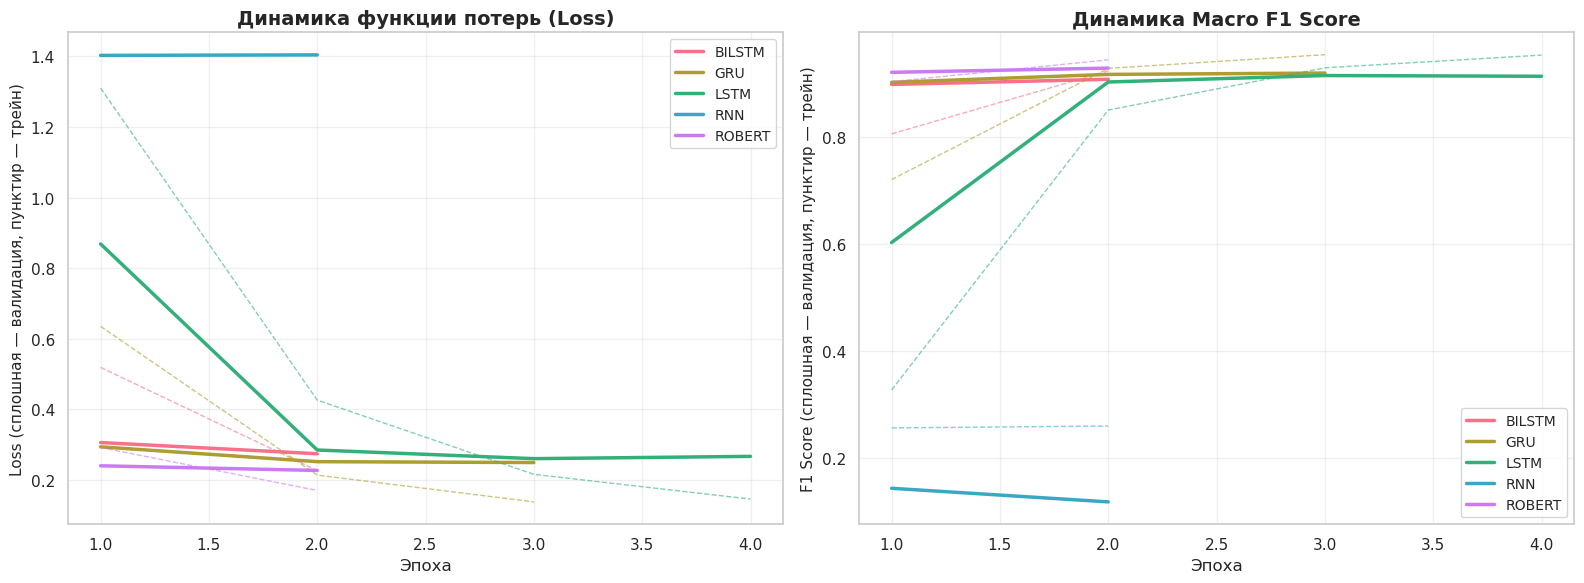

In [66]:
def plot_all_models(all_metrics):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    model_names = [m["model_name"] for m in all_metrics]
    palette = sns.color_palette("husl", len(model_names))
    colors = dict(zip(model_names, palette))
    
    for m in all_metrics:
        name = m["model_name"]
        history = pd.DataFrame(m["history"])
        color = colors[name]
        
        axes[0].plot(history["epoch"], history["tr_loss"], 
                     linestyle="--", color=color, alpha=0.6, linewidth=1)
        axes[0].plot(history["epoch"], history["va_loss"], 
                     linestyle="-", color=color, label=name.upper(), linewidth=2.5)
        
        axes[1].plot(history["epoch"], history["tr_f1"], 
                     linestyle="--", color=color, alpha=0.6, linewidth=1)
        axes[1].plot(history["epoch"], history["va_f1"], 
                     linestyle="-", color=color, label=name.upper(), linewidth=2.5)
    
    axes[0].set_title("Динамика функции потерь (Loss)", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Эпоха", fontsize=12)
    axes[0].set_ylabel("Loss (сплошная — валидация, пунктир — трейн)", fontsize=11)
    axes[0].legend(loc="upper right", fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_title("Динамика Macro F1 Score", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Эпоха", fontsize=12)
    axes[1].set_ylabel("F1 Score (сплошная — валидация, пунктир — трейн)", fontsize=11)
    axes[1].legend(loc="lower right", fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("work/models/all_models_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_all_models(all_metrics)

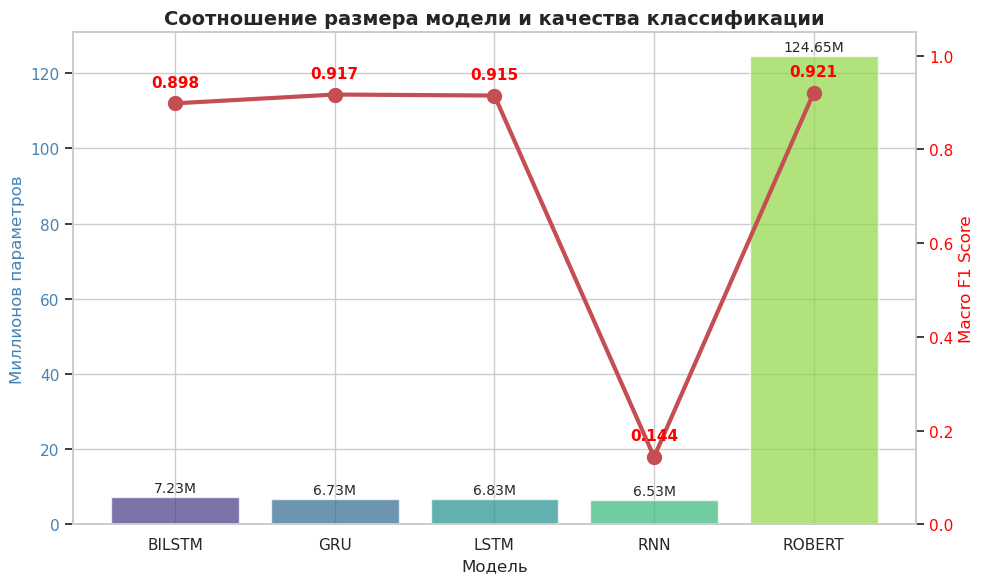

In [67]:
def plot_params_vs_quality(all_metrics):
    df = pd.DataFrame([
        {"model": m["model_name"].upper(), 
         "params": m["num_params"] / 1e6,
         "f1": m["best_f1"]}
        for m in all_metrics
    ])
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    bars = ax1.bar(df["model"], df["params"], 
                   color=sns.color_palette("viridis", len(df)), alpha=0.7)
    ax1.set_xlabel("Модель", fontsize=12)
    ax1.set_ylabel("Миллионов параметров", fontsize=12, color="steelblue")
    ax1.tick_params(axis="y", labelcolor="steelblue")
    
    for bar, params in zip(bars, df["params"]):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{params:.2f}M", ha="center", va="bottom", fontsize=10)
    
    ax2 = ax1.twinx()
    line = ax2.plot(df["model"], df["f1"], "ro-", linewidth=3, markersize=10,
                    label="Best Val F1")
    ax2.set_ylabel("Macro F1 Score", fontsize=12, color="red")
    ax2.tick_params(axis="y", labelcolor="red")
    ax2.set_ylim(0, 1.05)
    ax2.grid(False)
    
    for x, y in zip(df["model"], df["f1"]):
        ax2.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                     xytext=(0, 12), ha="center", fontsize=11, 
                     fontweight="bold", color="red")
    
    plt.title("Соотношение размера модели и качества классификации", 
              fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("work/models/params_vs_quality.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_params_vs_quality(all_metrics)